# 🌿 Olive Yield Across Mediterranean Countries: Environmental and Socioeconomic Factors

## Notebook 04: Predictive Modeling

## Introduction

Building on the Gold dataset created in "02_gold_dataset_engineering" notebokk and the exploratory analysis conducted in "03_exploratory_data_analysis" notebook, this notebook develops machine learning models to predict annual olive yield across 11 Mediterranean countries.

The exploratory analysis revealed substantial country-level differences in yield trends, historical variability, and environmental associations. This notebook evaluates whether agricultural, climate, soil, socioeconomic, demographic, and land-use indicators can support accurate yield prediction within a time-aware modeling framework.

Particular attention is given to target leakage, feature availability at prediction time, chronological validation, and performance differences across countries.

## Modeling Objectives

- Predict annual olive yield across the countries represented in the dataset.
- Identify and remove features that introduce target leakage or are unavailable at prediction time.
- Compare representative linear and nonlinear regression models.
- Evaluate models using chronological validation and an unseen test period.
- Determine whether machine learning improves upon a historical yield baseline.
- Examine prediction errors across countries and validation periods.

## Dataset at a Glance

- Source: Gold dataset created in Notebook 02
- Unit of analysis: Country-year
- Geographic coverage: 11 Mediterranean olive-producing countries
- Temporal coverage: 2000–2024
- Target: Annual olive yield in kg/ha
- Feature domains: Agriculture, climate, soil, economics, demographics, and land use

The dataset also includes engineered variables representing previous-year information, annual environmental changes, yield dynamics, and temporal dependencies.

## Candidate Feature Space

The initial feature space includes:

- Agricultural indicators: harvested area, olive production, previous-year yield, yield growth, and agricultural land indicators
- Climate indicators: temperature, temperature change from the historical baseline, precipitation, solar radiation, dew point, and wind speed
- Soil indicators: soil moisture and soil temperature at multiple depths
- Socioeconomic, demographic, and land-use indicators: GDP per capita, agriculture’s contribution to GDP, population, rural population share, and forest area share

These variables represent the initial candidate feature space rather than the final model inputs. Each feature is assessed for leakage, availability at prediction time, missingness, redundancy, and predictive contribution before model training.

### Modeling Strategy

The predictive workflow follows six stages:

1. Data preparation: Validate the panel structure, assess missingness, remove target leakage, and create a chronological train–test split.  
2. Feature screening: Examine feature variation, target relationships, country-level differences, and predictor redundancy.
3. Baseline evaluation: Evaluate a previous-year-yield benchmark and Linear Regression.
4. Model comparison: Compare representative linear, regularized, distance-based, kernel-based, and tree-based regressors using chronological validation.
5. Model selection and optimization: Select predictors and tune hyperparameters separately for the strongest candidate models.
6. Final assessment: Examine validation performance, learning behavior, test-period results, and country-level errors.

## Environment Setup

In [2]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization and display
import matplotlib.pyplot as plt
from IPython.display import display

# Model utilities
from sklearn.base import clone

# Data preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# Machine learning pipelines
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Model selection and validation
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_validate

# Model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Dataset Loading

Load the Gold dataset and preserve an unchanged copy for reference during preprocessing and modeling.

In [3]:
df= pd.read_csv("gold_olive_dataset.csv").copy()
print(f"Dataset loaded: {df.shape[0]} rows and {df.shape[1]} columns")
display(df.head())

Dataset loaded: 274 rows and 29 columns


,Country,Year,Area_Harvested_ha,Production_tonnes,Yield_kg_per_ha,Mean_Temperature_C,Mean_Dewpoint_C,Mean_Wind_Speed_m_s,Total_Precipitation_mm,Mean_Solar_Radiation_MJ_m2,...,Population,Rural_population_pct,Temperature_change,Previous_Year_Yield,Yield_Growth_Rate,Average_Soil_Moisture,Average_Soil_Temperature,Temperature_Yearly_Change,Precipitation_Yearly_Change,Soil_Moisture_Yearly_Change
0,Algeria,2000,168080.0,217112.0,1291.7,17.070543,8.165996,2.534910,311.594795,462.349999,...,30903893.0,40.147876,0.765,NaN,NaN,0.201134,16.963302,NaN,NaN,NaN
1,Algeria,2001,177220.0,200339.0,1130.5,17.351156,8.849744,2.526347,400.795290,452.271454,...,31331221.0,39.382283,1.793,1291.7,-0.124797,0.205318,17.325471,0.280613,89.200495,0.004184
2,Algeria,2002,190550.0,191926.0,1007.2,17.139296,8.822309,2.611674,422.704252,450.371879,...,31750835.0,38.618734,1.187,1130.5,-0.109067,0.194160,16.947261,-0.211860,21.908962,-0.011158
3,Algeria,2003,209730.0,167627.0,799.3,17.291044,9.750931,2.598855,679.290588,429.201066,...,32175818.0,37.857209,1.518,1007.2,-0.206414,0.234876,17.175396,0.151748,256.586336,0.040716
4,Algeria,2004,226337.0,468800.0,2071.2,16.630468,9.407756,2.540032,596.052643,434.578877,...,32628286.0,37.097687,0.920,799.3,1.591267,0.229283,16.426965,-0.660576,-83.237945,-0.005593


## Dataset Structure Validation

Sort observations chronologically and verify that each Country–Year combination identifies a unique record.

In [4]:
df = (
    df.sort_values(["Country", "Year"])
      .reset_index(drop=True)
)

duplicate_count = df.duplicated(
    subset=["Country", "Year"]
).sum()

print(f"Duplicate Country-Year records: {duplicate_count}")

Duplicate Country-Year records: 0


## Missing-Value Summary

Quantify missing values before examining their origin and selecting an appropriate modeling treatment.

In [5]:
missing_summary = (
    df.isna()
      .sum()
      .loc[lambda values: values > 0]
      .sort_values(ascending=False)
      .rename("Missing_Count")
      .to_frame()
)

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"] / len(df) * 100
).round(2)

missing_summary.index.name = "Feature"

display(missing_summary)

,Missing_Count,Missing_Percentage
Feature,,
Previous_Year_Yield,11,4.01
Temperature_Yearly_Change,11,4.01
Yield_Growth_Rate,11,4.01
Precipitation_Yearly_Change,11,4.01
Soil_Moisture_Yearly_Change,11,4.01
Agriculture_value_added_pct_GDP,4,1.46
GDP_per_capita,2,0.73


### Interpretation
Seven features contain missing values. Five engineered temporal features each contain 11 missing observations, representing 4.01% of the dataset.

Missingness is lower in the two economic indicators:  

- Agriculture_value_added_pct_GDP: 4 missing values (1.46%)  
- GDP_per_capita: 2 missing values (0.73%)  

The following analysis examines the location and origin of these missing values before determining how they should be handled during modeling.

## Preprocessing

### Target-Leakage and Redundancy Removal

Features that directly contain target information or duplicate information already represented by other variables are removed before modeling.

Production_tonnes is excluded because current-year olive yield is calculated using production and harvested area. Yield_Growth_Rate is also excluded because its calculation includes current-year yield and would therefore reveal information about the target.

For soil variables, measurements from the three moisture depths are retained to preserve layer-specific information, while their average is removed. Conversely, the two soil-temperature depth measurements are removed because they are highly similar, and their average is retained as a more concise representation.

In [6]:
leakage_columns = [
    "Production_tonnes",
    "Yield_Growth_Rate",
]

redundant_columns = [
    "Average_Soil_Moisture",
    "Mean_Soil_Temperature_7_28cm_C",
    "Mean_Soil_Temperature_28_100cm_C",
]

columns_to_drop = leakage_columns + redundant_columns

df = df.drop(columns=columns_to_drop)

print("Removed columns:", columns_to_drop)
print("Remaining dataset shape:", df.shape)

Removed columns: ['Production_tonnes', 'Yield_Growth_Rate', 'Average_Soil_Moisture', 'Mean_Soil_Temperature_7_28cm_C', 'Mean_Soil_Temperature_28_100cm_C']
Remaining dataset shape: (274, 24)


### Interpretation
Two target-leakage features and three redundant soil features were removed, leaving 274 observations and 24 variables, including the target.

This step ensures that model performance is not artificially inflated by features that directly contain current-year yield information, while retaining meaningful information from distinct soil layers.

### Chronological Train-Test Split

The dataset is split chronologically to reflect future-year prediction. Observations from 2000–2019 are used for model development, while 2020–2024 is reserved for final testing.

This prevents future observations from influencing models evaluated on earlier periods.

In [7]:
split_year = 2020

train_df = df[df["Year"] < split_year].copy()
test_df = df[df["Year"] >= split_year].copy()

print(
    f"Training set: {train_df.shape} "
    f"({len(train_df) / len(df):.1%})\n"
    f"Training period: "
    f"{train_df['Year'].min()}-{train_df['Year'].max()}\n\n"
    f"Test set: {test_df.shape} "
    f"({len(test_df) / len(df):.1%})\n"
    f"Test period: "
    f"{test_df['Year'].min()}-{test_df['Year'].max()}"
)

Training set: (220, 24) (80.3%)
Training period: 2000-2019

Test set: (54, 24) (19.7%)
Test period: 2020-2024


### Interpretation
The chronological split assigns 220 observations (80.3%) to model development and reserves 54 observations (19.7%) for final testing.

Model selection and validation will be performed using only the 2000–2019 training period. The 2020–2024 test set will remain untouched until the modeling workflow is finalized, providing a more realistic assessment of performance on future years.

### Definition of Predictors and Target

Separate olive yield from the predictor variables in the training and test sets.

In [8]:
X_train = train_df.drop(columns="Yield_kg_per_ha")
y_train = train_df["Yield_kg_per_ha"]

X_test = test_df.drop(columns="Yield_kg_per_ha")
y_test = test_df["Yield_kg_per_ha"]

print(
    f"Training set: {X_train.shape[0]} observations, "
    f"{X_train.shape[1]} predictors, and {len(y_train)} target values\n"
    f"Test set: {X_test.shape[0]} observations, "
    f"{X_test.shape[1]} predictors, and {len(y_test)} target values"
)

Training set: 220 observations, 23 predictors, and 220 target values
Test set: 54 observations, 23 predictors, and 54 target values


### Interpretation
The training set contains 220 observations and 23 predictors, while the test set contains 54 observations with the same predictor structure. Each observation has one corresponding olive-yield target value.

This is clearer than displaying raw shape tuples and immediately confirms that the predictors and targets are correctly aligned.

### Missing Values by Data Split

Examine missing values separately in the training and test sets so that treatment decisions are based only on the model-development period.

In [9]:
missing_by_split = pd.DataFrame({
    "Training_Missing": X_train.isna().sum(),
    "Test_Missing": X_test.isna().sum()
})

missing_by_split = missing_by_split[
    missing_by_split.sum(axis=1) > 0
]

display(missing_by_split)

,Training_Missing,Test_Missing
Agriculture_value_added_pct_GDP,2,2
GDP_per_capita,0,2
Previous_Year_Yield,11,0
Temperature_Yearly_Change,11,0
Precipitation_Yearly_Change,11,0
Soil_Moisture_Yearly_Change,11,0


### Interpretation
Two missing-value patterns require different treatment:

Temporal features: Four engineered features contain 11 missing training values, all corresponding to 2000 because observations from 1999 are unavailable.
Economic indicators: A small number of values are missing in both the training and test periods due to gaps in the original data sources.

Models requiring complete predictors will use the 209 fully observed training records, while models that support missing values will be evaluated using all 220 training records.

### Exclusion of Incomplete Economic Indicators

Agriculture_value_added_pct_GDP and GDP_per_capita have incomplete historical coverage and may not be consistently available at prediction time. They are therefore excluded from the primary modeling configuration rather than imputed using assumptions that could distort country-specific temporal patterns.

These indicators may be reconsidered if more complete and reliable data become available.

In [10]:
economic_columns = [
    "Agriculture_value_added_pct_GDP",
    "GDP_per_capita",
]

X_train_primary = X_train.drop(
    columns=economic_columns
).copy()

X_test_primary = X_test.drop(
    columns=economic_columns
).copy()

print(
    f"Primary training set: {X_train_primary.shape[0]} observations "
    f"and {X_train_primary.shape[1]} predictors\n"
    f"Primary test set: {X_test_primary.shape[0]} observations "
    f"and {X_test_primary.shape[1]} predictors"
)

Primary training set: 220 observations and 21 predictors
Primary test set: 54 observations and 21 predictors


### Interpretation
The two incomplete economic indicators were excluded from the primary configuration. The resulting datasets retain 220 training observations and 54 test observations, with 21 predictors in each set.

This decision preserves all observations while avoiding imputation based on uncertain assumptions. The potential predictive contribution of these economic indicators is not assessed in the primary modeling workflow and remains a limitation of the current feature set.

### Handling Initial Gaps in Temporal Features

Four temporal features are unavailable for each country’s first observation because their calculation for 2000 would require data from 1999.

Models requiring complete predictors will use the 209 fully observed training records. The complete 220-record training set is retained separately for models that support missing values natively.

In [11]:
temporal_features_with_initial_gaps = [
    "Previous_Year_Yield",
    "Temperature_Yearly_Change",
    "Precipitation_Yearly_Change",
    "Soil_Moisture_Yearly_Change",
]

# Identify training observations with complete temporal features
rows_without_initial_gaps = (
    X_train_primary[temporal_features_with_initial_gaps]
    .notna()
    .all(axis=1)
)

# Complete-data branch
X_train_no_missing = X_train_primary.loc[
    rows_without_initial_gaps
].copy()

y_train_no_missing = y_train.loc[
    rows_without_initial_gaps
].copy()

X_test_no_missing = X_test_primary.copy()
y_test_no_missing = y_test.copy()

print(
    f"Complete-data training set: "
    f"{X_train_no_missing.shape[0]} observations and "
    f"{X_train_no_missing.shape[1]} predictors\n"
    f"Test set: {X_test_no_missing.shape[0]} observations and "
    f"{X_test_no_missing.shape[1]} predictors\n"
    f"Full training set retained for compatible models: "
    f"{X_train_primary.shape[0]} observations"
)

Complete-data training set: 209 observations and 21 predictors
Test set: 54 observations and 21 predictors
Full training set retained for compatible models: 220 observations


### Interpretation
The complete-data branch contains 209 training observations and 21 predictors, while all 54 test observations are retained. The original 220-observation training set remains available for models that support missing values.

### One-Hot Encoding of Country

Convert Country into binary indicators so that models can use the categorical information without assigning countries an artificial numerical order. The encoder is fitted on the training data and then applied to the test data.

In [12]:
categorical_features = ["Country"]

country_encoder = ColumnTransformer(
    transformers=[
        (
            "country",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

country_encoder.set_output(transform="pandas")

X_train_no_missing_encoded = country_encoder.fit_transform(
    X_train_no_missing
)

X_test_no_missing_encoded = country_encoder.transform(
    X_test_no_missing
)

print(
    f"Encoded training set: "
    f"{X_train_no_missing_encoded.shape[0]} observations and "
    f"{X_train_no_missing_encoded.shape[1]} predictors\n"
    f"Encoded test set: "
    f"{X_test_no_missing_encoded.shape[0]} observations and "
    f"{X_test_no_missing_encoded.shape[1]} predictors"
)

Encoded training set: 209 observations and 31 predictors
Encoded test set: 54 observations and 31 predictors


### Interpretation
One-hot encoding converted Country into 11 binary indicators, producing 31 aligned predictors in both the training and test sets.

This allows the models to capture country-specific differences without imposing an artificial ranking between countries or using information from the test period.

## General Feature Screening

Feature screening is performed using the training data only. The analysis identifies constant predictors and examines relationships with the target and between predictors.

These results support feature selection but are not used as automatic removal rules because they may not capture nonlinear relationships or feature interactions.

### Zero-Variance Feature Screening

A zero-variance predictor has the same value across all training observations and cannot contribute to prediction.

The threshold is set to zero to remove only constant predictors. A higher threshold is not applied because the predictors use different measurement units, making their raw variances unsuitable for direct comparison. Applying standard scaling would give every nonconstant numerical predictor a variance close to one, while robust scaling would still require an arbitrary threshold. In addition, low variance does not necessarily imply low predictive value.

In [13]:
variance_selector = VarianceThreshold(threshold=0)
variance_selector.set_output(transform="pandas")

X_train_screened = variance_selector.fit_transform(
    X_train_no_missing_encoded
)

X_test_screened = variance_selector.transform(
    X_test_no_missing_encoded
)

print(
    f"Predictors before screening: "
    f"{X_train_no_missing_encoded.shape[1]}\n"
    f"Predictors after screening: "
    f"{X_train_screened.shape[1]}"
)

Predictors before screening: 31
Predictors after screening: 31


### Interpretation
No constant predictors were identified, so all 31 predictors were retained for the next screening stage.

This confirms that every candidate predictor contains variation within the training period and can potentially contribute information to the models.

### Correlation with Olive Yield

Pearson correlations are calculated between each numerical predictor and olive yield using the training data.

Pooled correlations capture differences both between countries and over time. To examine relationships within countries, each variable is also centered around its country-specific training-period mean. Country indicators are excluded because they represent one categorical feature rather than independent numerical measurements.

In [15]:
# Select the original numerical predictors
numerical_features_original = (
    X_train_no_missing
    .select_dtypes(include="number")
    .columns
)

# Calculate pooled correlations with olive yield
pooled_correlations = (
    X_train_no_missing[numerical_features_original]
    .corrwith(y_train_no_missing)
)

# Center predictors around their country-specific means
X_train_country_adjusted = (
    X_train_no_missing[numerical_features_original]
    - X_train_no_missing
    .groupby("Country")[numerical_features_original]
    .transform("mean")
)

# Center the target around its country-specific mean
y_train_country_adjusted = (
    y_train_no_missing
    - y_train_no_missing
    .groupby(X_train_no_missing["Country"])
    .transform("mean")
)

# Calculate correlations after country-mean adjustment
country_adjusted_correlations = (
    X_train_country_adjusted
    .corrwith(y_train_country_adjusted)
)

# Compare pooled and country-adjusted correlations
correlation_comparison = pd.DataFrame({
    "Pooled Correlation": pooled_correlations,
    "Country-Adjusted Correlation": country_adjusted_correlations,
})

correlation_comparison["Absolute Adjusted Correlation"] = (
    correlation_comparison["Country-Adjusted Correlation"].abs()
)

correlation_comparison = correlation_comparison.sort_values(
    "Absolute Adjusted Correlation",
    ascending=False,
)

display(correlation_comparison.round(3))

,Pooled Correlation,Country-Adjusted Correlation,Absolute Adjusted Correlation
Previous_Year_Yield,0.951,0.548,0.548
Population,0.688,0.536,0.536
Year,0.080,0.248,0.248
Mean_Soil_Moisture_7_28cm,-0.528,-0.199,0.199
Mean_Wind_Speed_m_s,0.326,-0.101,0.101
Mean_Soil_Moisture_28_100cm,-0.396,-0.093,0.093
Soil_Moisture_Yearly_Change,0.002,0.081,0.081
Area_Harvested_ha,-0.220,0.077,0.077
Average_Soil_Temperature,0.352,0.073,0.073
Temperature_Yearly_Change,-0.003,-0.059,0.059


### Interpretation
Centering the data within countries substantially changes several relationships, showing that many pooled correlations are driven by persistent differences between countries.

Previous_Year_Yield remains the strongest predictor, although its correlation decreases from 0.951 pooled to 0.548 within countries. Population also retains a relatively strong within-country correlation of 0.536, while most climate, soil, and land-use indicators become considerably weaker.

The strong population result should be interpreted cautiously because population and olive yield may both follow long-term trends within countries. It does not necessarily indicate a direct relationship.

No predictors are removed at this stage. Correlation measures linear relationships only and may not capture nonlinear patterns, feature interactions, or country-specific effects that the candidate models could use.

#### Previous-Year Yield Correlation by Country

The country-adjusted correlation still summarizes all observations together. Correlations are therefore calculated separately by country to assess whether year-to-year yield persistence is consistent across the dataset.

In [25]:
yield_correlations_by_country = (
    train_df[
        ["Country", "Yield_kg_per_ha", "Previous_Year_Yield"]
    ]
    .dropna()
    .groupby("Country")
    .apply(
        lambda country_data: pd.Series({
            "Observations": len(country_data),
            "Correlation": country_data[
                "Yield_kg_per_ha"
            ].corr(
                country_data["Previous_Year_Yield"]
            )
        }),
        include_groups=False
    )
    .reset_index()
    .sort_values(
        "Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

yield_correlations_by_country["Observations"] = (
    yield_correlations_by_country["Observations"]
    .astype(int)
)

display(yield_correlations_by_country.round(3))

,Country,Observations,Correlation
0,Libya,19,0.902
1,Egypt,19,0.746
2,Portugal,19,0.677
3,Italy,19,0.654
4,Morocco,19,0.149
5,Algeria,19,0.146
6,Greece,19,-0.158
7,Tunisia,19,-0.177
8,Syria,19,-0.349
9,Spain,19,-0.401


### Interpretation
The relationship between current and previous-year yield varies considerably across countries. Libya, Egypt, Portugal, and Italy show positive year-to-year persistence, while several other countries show weak or negative correlations.

The strong pooled correlation therefore does not represent a common temporal pattern across all countries. Previous_Year_Yield remains a candidate predictor, but its value will be determined by chronological model performance rather than correlation alone.

Each country-level coefficient is based on 19 observations, so the results should be treated as exploratory rather than definitive.

### Correlation Between Numerical Predictors

Absolute correlations between numerical predictors are examined to identify potential redundancy and multicollinearity.

Pooled correlations are compared with correlations calculated after country-mean adjustment. This helps distinguish relationships driven by persistent differences between countries from those that remain after those differences are reduced. Correlation alone is not used as an automatic feature-removal rule.

In [16]:
# Calculate absolute pooled and country-adjusted correlations
pooled_predictor_correlations = (
    X_train_no_missing[numerical_features_original]
    .corr()
    .abs()
)

adjusted_predictor_correlations = (
    X_train_country_adjusted
    .corr()
    .abs()
)

# Retain each feature pair only once
upper_triangle_mask = np.triu(
    np.ones(pooled_predictor_correlations.shape),
    k=1,
).astype(bool)

pooled_pairs = (
    pooled_predictor_correlations
    .where(upper_triangle_mask)
    .stack()
    .rename("Absolute Pooled Correlation")
)

adjusted_pairs = (
    adjusted_predictor_correlations
    .where(upper_triangle_mask)
    .stack()
    .rename("Absolute Country-Adjusted Correlation")
)

# Compare pooled and country-adjusted relationships
predictor_correlation_comparison = (
    pd.concat(
        [pooled_pairs, adjusted_pairs],
        axis=1,
    )
    .reset_index()
)

predictor_correlation_comparison.columns = [
    "Feature 1",
    "Feature 2",
    "Absolute Pooled Correlation",
    "Absolute Country-Adjusted Correlation",
]

predictor_correlation_comparison = (
    predictor_correlation_comparison
    .sort_values(
        "Absolute Country-Adjusted Correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    predictor_correlation_comparison.head(15).round(3)
)

,Feature 1,Feature 2,Absolute Pooled Correlation,Absolute Country-Adjusted Correlation
0,Mean_Temperature_C,Average_Soil_Temperature,0.986,0.947
1,Temperature_change,Average_Soil_Temperature,0.006,0.878
2,Mean_Temperature_C,Temperature_change,0.035,0.874
3,Mean_Soil_Moisture_0_7cm,Mean_Soil_Moisture_7_28cm,0.943,0.840
4,Mean_Soil_Moisture_7_28cm,Mean_Soil_Moisture_28_100cm,0.924,0.839
5,Mean_Solar_Radiation_MJ_m2,Mean_Soil_Moisture_0_7cm,0.323,0.837
6,Total_Precipitation_mm,Mean_Soil_Moisture_0_7cm,0.904,0.819
7,Total_Precipitation_mm,Mean_Solar_Radiation_MJ_m2,0.098,0.805
8,Precipitation_Yearly_Change,Soil_Moisture_Yearly_Change,0.748,0.748
9,Mean_Soil_Moisture_0_7cm,Soil_Moisture_Yearly_Change,0.128,0.716


### Interpretation
Strong within-country relationships remain among temperature, soil moisture, precipitation, and solar radiation variables. Some relationships become stronger after removing country-level averages, indicating that correlations calculated across the full dataset can mask patterns occurring within individual countries.

These relationships suggest potential multicollinearity, but no predictors are removed at this stage. Their predictive value and redundancy will instead be assessed through model-specific feature selection and chronological validation.

### General Feature Screening Conclusion

No constant predictors were identified, and the correlation analysis highlighted potential redundancy without providing a sufficient basis for removing additional features at this stage.

The screening also revealed substantial country-level heterogeneity and strong relationships among several environmental predictors. Consequently, all 31 candidate predictors are retained for the initial model comparison, while feature reduction will be performed separately for the strongest candidate models using chronological validation.

## Model Evaluation Framework

Model development uses expanding-window chronological validation to preserve temporal order. Because lagged and year-over-year features are unavailable in 2000, the modeling period begins in 2001.

The years 2020–2024 are reserved as an untouched test period and are used only for the final evaluation.

### Chronological Cross-Validation

Each fold trains on all available years preceding its validation period. All countries from the same validation year are evaluated together, preventing observations from the same year from being split between training and validation.

In [18]:
training_years = train_df.loc[
    X_train_screened.index,
    "Year"
]

validation_periods = [
    (2013, 2014),
    (2015, 2016),
    (2017, 2018),
    (2019, 2019),
]

time_folds = []
fold_summary = []

for fold_number, (validation_start, validation_end) in enumerate(
    validation_periods,
    start=1
):
    fold_train_indices = np.flatnonzero(
        training_years < validation_start
    )

    fold_validation_indices = np.flatnonzero(
        training_years.between(
            validation_start,
            validation_end
        )
    )

    validation_label = (
        str(validation_start)
        if validation_start == validation_end
        else f"{validation_start}–{validation_end}"
    )

    time_folds.append(
        (fold_train_indices, fold_validation_indices)
    )

    fold_summary.append({
        "Fold": fold_number,
        "Training_Period": (
            f"{training_years.iloc[fold_train_indices].min()}–"
            f"{training_years.iloc[fold_train_indices].max()}"
        ),
        "Validation_Period": validation_label,
        "Training_Observations": len(fold_train_indices),
        "Validation_Observations": len(fold_validation_indices),
    })

fold_summary = pd.DataFrame(fold_summary)

display(fold_summary)

,Fold,Training_Period,Validation_Period,Training_Observations,Validation_Observations
0,1,2001–2012,2013–2014,132,22
1,2,2001–2014,2015–2016,154,22
2,3,2001–2016,2017–2018,176,22
3,4,2001–2018,2019,198,11


### Interpretation
The expanding-window design preserves temporal order: each model is trained only on observations preceding its validation period. As the training window expands from 2001–2012 to 2001–2018, the models are evaluated on progressively more recent years.

The first three folds each contain two validation years and 22 observations. The final fold evaluates 2019 separately using 11 observations, allowing the most recent pre-test year to be assessed before the untouched 2020–2024 test period.

This framework provides a more realistic estimate of future-year performance than a random split and ensures that the final test results remain independent of model comparison, feature selection, and hyperparameter tuning.

### Evaluation Metrics

MAE is the primary evaluation metric because it expresses the average absolute prediction error directly in kg/ha. RMSE gives greater weight to larger errors, while R² measures the proportion of yield variation explained by the model.

In [21]:
scoring_metrics = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

Note: Scikit-learn returns MAE and RMSE as negative scores during cross-validation. Their signs are reversed when reporting results so that lower positive values indicate better performance.

## Baseline Models

A simple reference prediction is evaluated before the machine learning models.
This establishes the minimum performance that a trained model should improve upon.

### Previous-Year Yield Baseline

The baseline predicts each country’s current yield using its observed yield from the previous year. It requires no model training and is evaluated on the same chronological validation periods as the candidate models.

In [19]:
previous_year_baseline_results = []

for (validation_start, validation_end), (_, validation_indices) in zip(
    validation_periods,
    time_folds,
):
    y_validation = y_train_no_missing.iloc[
        validation_indices
    ]

    baseline_predictions = X_train_screened.iloc[
        validation_indices
    ]["Previous_Year_Yield"]

    validation_period = (
        str(validation_start)
        if validation_start == validation_end
        else f"{validation_start}–{validation_end}"
    )

    previous_year_baseline_results.append(
        {
            "Validation_Period": validation_period,
            "MAE": mean_absolute_error(
                y_validation,
                baseline_predictions,
            ),
            "RMSE": mean_squared_error(
                y_validation,
                baseline_predictions,
            )
            ** 0.5,
            "R2": r2_score(
                y_validation,
                baseline_predictions,
            ),
        }
    )

previous_year_baseline_results = pd.DataFrame(
    previous_year_baseline_results
)

# Display performance for each chronological fold
display(previous_year_baseline_results.round(3))

# Summarize average performance and variation across folds
baseline_summary = previous_year_baseline_results[
    ["MAE", "RMSE", "R2"]
].agg(["mean", "std"])

display(baseline_summary.round(3))

,Validation_Period,MAE,RMSE,R2
0,2013–2014,591.186,815.774,0.873
1,2015–2016,447.641,544.152,0.958
2,2017–2018,417.836,534.323,0.969
3,2019,553.364,933.027,0.843


,MAE,RMSE,R2
mean,502.507,706.819,0.911
std,82.925,199.380,0.063


### Interpretation
The previous-year baseline achieves a validation MAE of 502.51 ± 82.93 kg/ha, an RMSE of 706.82 ± 199.38 kg/ha, and an R² of 0.911 ± 0.062 across the chronological folds.

The baseline performs well overall, confirming that the previous year’s yield is a strong predictor of current yield. However, performance varies across periods, with 2019 recording the highest RMSE and lowest R².

This establishes a demanding benchmark: candidate models should improve average prediction accuracy while maintaining consistent performance across validation periods.

### Linear Regression Baseline

Linear Regression is evaluated as the first trained model. It estimates a common linear relationship between the predictors and olive yield, while country indicators account for differences in average yield levels.

Country_Algeria is used as the reference category to avoid exact redundancy between the intercept and the full set of country indicators. Algerian observations remain in the dataset.

In [22]:
reference_country = "Country_Algeria"

X_train_linear = X_train_screened.drop(
    columns=reference_country
)

linear_model = LinearRegression()

linear_validation = cross_validate(
    estimator=linear_model,
    X=X_train_linear,
    y=y_train_no_missing,
    cv=time_folds,
    scoring=scoring_metrics,
    n_jobs=-1,
)

validation_labels = [
    (
        str(validation_start)
        if validation_start == validation_end
        else f"{validation_start}–{validation_end}"
    )
    for validation_start, validation_end in validation_periods
]

linear_regression_results = pd.DataFrame(
    {
        "Validation_Period": validation_labels,
        "MAE": -linear_validation["test_MAE"],
        "RMSE": -linear_validation["test_RMSE"],
        "R2": linear_validation["test_R2"],
    }
)

# Display performance for each chronological fold
display(linear_regression_results.round(3))

# Summarize average performance and variation across folds
linear_summary = linear_regression_results[
    ["MAE", "RMSE", "R2"]
].agg(["mean", "std"])

display(linear_summary.round(3))

,Validation_Period,MAE,RMSE,R2
0,2013–2014,588.444,771.008,0.886
1,2015–2016,530.936,624.990,0.945
2,2017–2018,434.599,568.220,0.965
3,2019,609.997,924.806,0.846


,MAE,RMSE,R2
mean,540.994,722.256,0.911
std,78.388,159.782,0.055


### Interpretation
Linear Regression achieves a validation MAE of 540.99 ± 78.39 kg/ha, an RMSE of 722.26 ± 159.78 kg/ha, and an R² of 0.910 ± 0.055 across the chronological folds.

The model does not improve upon the previous-year baseline, which records lower average MAE and RMSE with a comparable R². Performance also varies across periods, with the highest errors occurring in 2019.

Linear Regression is therefore retained as the simplest trained reference, while regularized and nonlinear models are evaluated next.

## Initial Model Comparison

Representative regression models are compared using the same candidate predictors, chronological validation folds, and evaluation metrics.

Scale-sensitive models use RobustScaler for numerical predictors, while country indicators remain unchanged. Preprocessing and estimation are combined in pipelines so that all transformations are fitted separately within each training fold. Tree-based models use the original feature values because they do not require scaling.

Linear Regression omits Country_Algeria as the reference category. Other models retain all country indicators, including KNN, for which a symmetric country representation is particularly important.

In [24]:
country_indicators = [
    column
    for column in X_train_screened.columns
    if column.startswith("Country_")
]

numerical_features = [
    column
    for column in X_train_screened.columns
    if column not in country_indicators
]

# Linear Regression uses Algeria as the reference country
reference_country = "Country_Algeria"

X_train_linear = X_train_screened.drop(
    columns=reference_country
)

linear_country_indicators = [
    column
    for column in country_indicators
    if column != reference_country
]

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            RobustScaler(),
            numerical_features,
        ),
        (
            "country",
            "passthrough",
            linear_country_indicators,
        ),
    ],
    verbose_feature_names_out=False,
)

# Other scale-sensitive models retain all country indicators
scaled_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            RobustScaler(),
            numerical_features,
        ),
        (
            "country",
            "passthrough",
            country_indicators,
        ),
    ],
    verbose_feature_names_out=False,
)

candidate_models = {
    "Linear Regression": (
        Pipeline([
            ("preprocessor", linear_preprocessor),
            ("regressor", LinearRegression()),
        ]),
        X_train_linear,
    ),
    "Ridge": (
        Pipeline([
            ("preprocessor", scaled_preprocessor),
            ("regressor", Ridge(alpha=1.0)),
        ]),
        X_train_screened,
    ),
    "Lasso": (
        Pipeline([
            ("preprocessor", scaled_preprocessor),
            (
                "regressor",
                Lasso(
                    alpha=1.0,
                    max_iter=20000,
                ),
            ),
        ]),
        X_train_screened,
    ),
    "Elastic Net": (
        Pipeline([
            ("preprocessor", scaled_preprocessor),
            (
                "regressor",
                ElasticNet(
                    alpha=1.0,
                    l1_ratio=0.5,
                    max_iter=20000,
                ),
            ),
        ]),
        X_train_screened,
    ),
    "SVR": (
        Pipeline([
            ("preprocessor", scaled_preprocessor),
            ("regressor", SVR()),
        ]),
        X_train_screened,
    ),
    "KNN": (
        Pipeline([
            ("preprocessor", scaled_preprocessor),
            ("regressor", KNeighborsRegressor()),
        ]),
        X_train_screened,
    ),
    "Decision Tree": (
        DecisionTreeRegressor(random_state=42),
        X_train_screened,
    ),
    "Random Forest": (
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
        ),
        X_train_screened,
    ),
    "Extra Trees": (
        ExtraTreesRegressor(
            random_state=42,
            n_jobs=-1,
        ),
        X_train_screened,
    ),
    "Gradient Boosting": (
        GradientBoostingRegressor(random_state=42),
        X_train_screened,
    ),
}

initial_model_results = []
initial_fold_results = []

for model_name, (model, model_predictors) in candidate_models.items():
    validation_results = cross_validate(
        estimator=model,
        X=model_predictors,
        y=y_train_no_missing,
        cv=time_folds,
        scoring=scoring_metrics,
        n_jobs=-1,
    )

    fold_mae = -validation_results["test_MAE"]
    fold_rmse = -validation_results["test_RMSE"]
    fold_r2 = validation_results["test_R2"]

    initial_model_results.append(
        {
            "Model": model_name,
            "Mean_MAE": fold_mae.mean(),
            "MAE_Std": fold_mae.std(),
            "Mean_RMSE": fold_rmse.mean(),
            "RMSE_Std": fold_rmse.std(),
            "Mean_R2": fold_r2.mean(),
            "R2_Std": fold_r2.std(),
        }
    )

    for validation_period, mae, rmse, r2 in zip(
        validation_labels,
        fold_mae,
        fold_rmse,
        fold_r2,
    ):
        initial_fold_results.append(
            {
                "Model": model_name,
                "Validation_Period": validation_period,
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2,
            }
        )

initial_model_comparison = (
    pd.DataFrame(initial_model_results)
    .sort_values("Mean_MAE")
    .reset_index(drop=True)
)

initial_fold_comparison = pd.DataFrame(
    initial_fold_results
)

# Display average performance and variation across folds
display(initial_model_comparison.round(3))

# Display fold-level results for the three leading candidates
leading_models = initial_model_comparison.head(3)["Model"].tolist()

display(
    initial_fold_comparison[
        initial_fold_comparison["Model"].isin(leading_models)
    ]
    .sort_values(["Model", "Validation_Period"])
    .reset_index(drop=True)
    .round(3)
)

,Model,Mean_MAE,MAE_Std,Mean_RMSE,RMSE_Std,Mean_R2,R2_Std
0,KNN,429.714,57.631,608.972,153.561,0.944,0.019
1,Extra Trees,451.071,44.426,673.525,91.067,0.932,0.008
2,Ridge,480.151,59.475,642.029,86.511,0.932,0.030
3,Lasso,489.767,68.293,662.321,90.471,0.929,0.030
4,Random Forest,521.869,80.744,743.719,142.259,0.918,0.013
5,Gradient Boosting,531.282,28.345,759.013,24.717,0.911,0.017
6,Linear Regression,544.251,40.566,720.440,80.606,0.915,0.034
7,Elastic Net,617.788,98.486,805.928,146.200,0.902,0.025
8,Decision Tree,700.034,228.015,1174.025,562.987,0.786,0.158
9,SVR,1416.576,134.141,2741.311,328.299,-0.121,0.012


,Model,Validation_Period,MAE,RMSE,R2
0,Extra Trees,2013–2014,396.658,550.369,0.942
1,Extra Trees,2015–2016,433.567,674.755,0.936
2,Extra Trees,2017–2018,518.979,807.190,0.930
3,Extra Trees,2019,455.078,661.784,0.921
4,KNN,2013–2014,445.151,603.920,0.930
5,KNN,2015–2016,369.587,518.678,0.962
6,KNN,2017–2018,516.995,858.635,0.921
7,KNN,2019,387.124,454.654,0.963
8,Ridge,2013–2014,454.770,641.701,0.921
9,Ridge,2015–2016,450.472,576.801,0.953


### Interpretation
KNN delivers the strongest initial validation performance, achieving the lowest mean MAE and RMSE and the highest mean R². Its MAE of 429.71 ± 57.63 kg/ha represents an improvement of approximately 14.5% over the previous-year baseline.

Extra Trees ranks second by mean MAE and shows the lowest MAE variation among the three leading candidates. Ridge provides the strongest regularized linear result, while SVR and Decision Tree perform substantially worse under their initial configurations.

KNN, Extra Trees, and Ridge are therefore retained for model-specific feature selection and hyperparameter optimization. Final model selection should consider both average validation accuracy and consistency across chronological folds.

### Evaluation of the Initial Temporal Gaps

The fully observed modeling branch excludes the first observation for each country because four engineered temporal features require previous-year information. This leaves 209 training observations.

This experiment retains all 220 observations and evaluates HistGradientBoostingRegressor, which supports missing numerical values, using the same chronological validation periods and evaluation metrics.

In [26]:
# Preprocess country as one-hot encoded indicators while retaining
# all numerical predictors, including their missing values
native_missing_preprocessor = ColumnTransformer(
    transformers=[
        (
            "country",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            ["Country"],
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

# HistGradientBoosting supports missing numerical values natively
native_missing_model = Pipeline(
    steps=[
        (
            "preprocessor",
            native_missing_preprocessor,
        ),
        (
            "regressor",
            HistGradientBoostingRegressor(
                random_state=42,
            ),
        ),
    ]
)

# Retrieve the year associated with each retained training observation
native_training_years = train_df.loc[
    X_train_primary.index,
    "Year",
]

# Recreate the same chronological validation folds
native_time_folds = []

for validation_start, validation_end in validation_periods:
    native_train_indices = np.flatnonzero(
        native_training_years < validation_start
    )

    native_validation_indices = np.flatnonzero(
        native_training_years.between(
            validation_start,
            validation_end,
        )
    )

    native_time_folds.append(
        (
            native_train_indices,
            native_validation_indices,
        )
    )

# Evaluate the model using chronological cross-validation
native_missing_validation = cross_validate(
    estimator=native_missing_model,
    X=X_train_primary,
    y=y_train,
    cv=native_time_folds,
    scoring=scoring_metrics,
    n_jobs=-1,
)

# Store fold-level results
native_missing_results = pd.DataFrame(
    {
        "Validation_Period": validation_labels,
        "MAE": -native_missing_validation["test_MAE"],
        "RMSE": -native_missing_validation["test_RMSE"],
        "R2": native_missing_validation["test_R2"],
    }
)

# Summarize average performance and variation across folds
native_missing_summary = (
    native_missing_results[
        ["MAE", "RMSE", "R2"]
    ]
    .agg(["mean", "std"])
    .rename(
        index={
            "mean": "Mean",
            "std": "Standard Deviation",
        }
    )
)

print(
    f"Training observations retained: "
    f"{X_train_primary.shape[0]}"
)

display(native_missing_results.round(3))
display(native_missing_summary.round(3))

Training observations retained: 220


,Validation_Period,MAE,RMSE,R2
0,2013–2014,580.877,726.175,0.899
1,2015–2016,586.810,804.966,0.909
2,2017–2018,718.383,1034.245,0.885
3,2019,408.080,433.008,0.966


,MAE,RMSE,R2
Mean,573.538,749.598,0.915
Standard Deviation,127.261,248.239,0.036


### Interpretation
HistGradientBoosting retains all 220 training observations but achieves a validation MAE of 573.54 ± 110.21 kg/ha, an RMSE of 749.60 ± 214.98 kg/ha, and an R² of 0.915 ± 0.031.

Performance varies substantially across periods: the highest MAE and RMSE occur in 2017–2018, while 2019 produces the strongest results. Retaining the 11 first-year observations therefore does not improve average validation performance under this initial configuration.

The fully observed 209-observation branch remains the preferred path for the subsequent model-selection stage, where KNN, Extra Trees, and Ridge are retained as the leading candidates.

## Model-Specific Feature Selection

The initial comparison identified KNN, Extra Trees, and Ridge as the strongest candidates. Feature selection is performed separately for each model because predictor relevance depends on the algorithm.

KNN is sensitive to irrelevant and redundant predictors because predictions depend on distances between observations. Sequential forward selection therefore adds the numerical predictor that produces the largest reduction in mean chronological validation MAE at each step.

All 11 country indicators are retained to preserve country identity. Numerical predictors are scaled within each training fold, and selection stops when no remaining feature improves validation MAE.

In [28]:
country_only_model = KNeighborsRegressor()

knn_best_mae = -cross_val_score(
    estimator=country_only_model,
    X=X_train_screened[country_indicators],
    y=y_train_no_missing,
    cv=time_folds,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
).mean()

selected_knn_numerical_features = []
remaining_knn_features = numerical_features.copy()
knn_selection_history = []

while remaining_knn_features:

    candidate_results = []

    for candidate_feature in remaining_knn_features:

        candidate_numerical_features = (
            selected_knn_numerical_features
            + [candidate_feature]
        )

        candidate_features = (
            country_indicators
            + candidate_numerical_features
        )

        candidate_preprocessor = ColumnTransformer(
            transformers=[
                (
                    "numerical",
                    RobustScaler(),
                    candidate_numerical_features
                ),
                (
                    "country",
                    "passthrough",
                    country_indicators
                )
            ],
            verbose_feature_names_out=False
        )

        candidate_model = Pipeline(
            steps=[
                ("preprocessor", candidate_preprocessor),
                ("regressor", KNeighborsRegressor())
            ]
        )

        candidate_mae = -cross_val_score(
            estimator=candidate_model,
            X=X_train_screened[candidate_features],
            y=y_train_no_missing,
            cv=time_folds,
            scoring="neg_mean_absolute_error",
            n_jobs=-1
        ).mean()

        candidate_results.append({
            "Feature": candidate_feature,
            "Mean_MAE": candidate_mae
        })

    candidate_results = (
        pd.DataFrame(candidate_results)
          .sort_values("Mean_MAE")
          .reset_index(drop=True)
    )

    best_candidate = candidate_results.iloc[0]

    if best_candidate["Mean_MAE"] >= knn_best_mae:
        break

    selected_feature = best_candidate["Feature"]
    knn_best_mae = best_candidate["Mean_MAE"]

    selected_knn_numerical_features.append(
        selected_feature
    )

    remaining_knn_features.remove(
        selected_feature
    )

    knn_selection_history.append({
        "Step": len(knn_selection_history) + 1,
        "Added_Feature": selected_feature,
        "Selected_Numerical_Features": len(
            selected_knn_numerical_features
        ),
        "Mean_Validation_MAE": knn_best_mae
    })

knn_selection_history = pd.DataFrame(
    knn_selection_history
)

selected_knn_features = (
    country_indicators
    + selected_knn_numerical_features
)

display(knn_selection_history.round(3))

print(
    "Selected numerical predictors:",
    len(selected_knn_numerical_features)
)

print(
    "Total predictors:",
    len(selected_knn_features)
)

print(
    "Best validation MAE:",
    round(knn_best_mae, 3),
    "kg/ha"
)

print("\nSelected numerical predictors:")

for feature in selected_knn_numerical_features:
    print("-", feature)

,Step,Added_Feature,Selected_Numerical_Features,Mean_Validation_MAE
0,1,Year,1,401.230
1,2,Mean_Soil_Moisture_7_28cm,2,392.333
2,3,Total_Precipitation_mm,3,385.747
3,4,Rural_population_pct,4,379.782


Selected numerical predictors: 4
Total predictors: 15
Best validation MAE: 379.782 kg/ha

Selected numerical predictors:
- Year
- Mean_Soil_Moisture_7_28cm
- Total_Precipitation_mm
- Rural_population_pct


### Interpretation
Sequential forward selection retained four numerical predictors:

- Year  
- Mean_Soil_Moisture_7_28cm  
- Total_Precipitation_mm  
- Rural_population_pct  

Validation MAE decreased at every step, from 401.23 kg/ha after adding Year to 379.78 kg/ha with all four selected predictors. Together with the 11 country indicators, the KNN-specific subset contains 15 predictors.

The selected features capture temporal progression, soil moisture, precipitation, and rural context while substantially reducing the original feature space. However, the subset remains provisional until its performance is compared with the complete 31-predictor KNN configuration across all validation metrics and chronological folds.

### Extra Trees Feature Selection

Extra Trees captures nonlinear relationships and feature interactions, but unnecessary predictors may increase model complexity. Sequential forward selection retains all 11 country indicators and adds the numerical predictor that produces the largest reduction in chronological validation MAE. Selection stops when no remaining predictor improves performance.

In [29]:
extra_trees_model = ExtraTreesRegressor(
    random_state=42,
    n_jobs=1
)

extra_trees_best_mae = -cross_val_score(
    estimator=extra_trees_model,
    X=X_train_screened[country_indicators],
    y=y_train_no_missing,
    cv=time_folds,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
).mean()

selected_extra_trees_numerical_features = []
remaining_extra_trees_features = numerical_features.copy()
extra_trees_selection_history = []

while remaining_extra_trees_features:

    candidate_results = []

    for candidate_feature in remaining_extra_trees_features:

        candidate_numerical_features = (
            selected_extra_trees_numerical_features
            + [candidate_feature]
        )

        candidate_features = (
            country_indicators
            + candidate_numerical_features
        )

        candidate_model = ExtraTreesRegressor(
            random_state=42,
            n_jobs=1
        )

        candidate_mae = -cross_val_score(
            estimator=candidate_model,
            X=X_train_screened[candidate_features],
            y=y_train_no_missing,
            cv=time_folds,
            scoring="neg_mean_absolute_error",
            n_jobs=-1
        ).mean()

        candidate_results.append({
            "Feature": candidate_feature,
            "Mean_MAE": candidate_mae
        })

    candidate_results = (
        pd.DataFrame(candidate_results)
          .sort_values("Mean_MAE")
          .reset_index(drop=True)
    )

    best_candidate = candidate_results.iloc[0]

    if best_candidate["Mean_MAE"] >= extra_trees_best_mae:
        break

    selected_feature = best_candidate["Feature"]
    extra_trees_best_mae = best_candidate["Mean_MAE"]

    selected_extra_trees_numerical_features.append(
        selected_feature
    )

    remaining_extra_trees_features.remove(
        selected_feature
    )

    extra_trees_selection_history.append({
        "Step": len(extra_trees_selection_history) + 1,
        "Added_Feature": selected_feature,
        "Selected_Numerical_Features": len(
            selected_extra_trees_numerical_features
        ),
        "Mean_Validation_MAE": extra_trees_best_mae
    })

extra_trees_selection_history = pd.DataFrame(
    extra_trees_selection_history
)

selected_extra_trees_features = (
    country_indicators
    + selected_extra_trees_numerical_features
)

display(extra_trees_selection_history.round(3))

print(
    "Selected numerical predictors:",
    len(selected_extra_trees_numerical_features)
)

print(
    "Total predictors:",
    len(selected_extra_trees_features)
)

print(
    "Best validation MAE:",
    round(extra_trees_best_mae, 3),
    "kg/ha"
)

print("\nSelected numerical predictors:")

for feature in selected_extra_trees_numerical_features:
    print("-", feature)

,Step,Added_Feature,Selected_Numerical_Features,Mean_Validation_MAE
0,1,Year,1,466.524
1,2,Soil_Moisture_Yearly_Change,2,397.788


Selected numerical predictors: 2
Total predictors: 13
Best validation MAE: 397.788 kg/ha

Selected numerical predictors:
- Year
- Soil_Moisture_Yearly_Change


### Interpretation
Sequential forward selection retained two numerical predictors:

- Year  
- Soil_Moisture_Yearly_Change  

Adding these predictors reduced validation MAE from 547.04 kg/ha with country indicators alone to 397.79 kg/ha. Together with the 11 country indicators, the reduced Extra Trees configuration contains 13 predictors.

The substantial improvement following the addition of Soil_Moisture_Yearly_Change suggests that changes in soil moisture provide useful predictive information for Extra Trees. However, the selected subset remains provisional until it is compared with the full 31-predictor configuration using the same chronological validation metrics.

### Ridge Feature Selection

Ridge reduces coefficient instability caused by correlated predictors, while a smaller feature set may improve validation performance and interpretability. Sequential forward selection retains all 11 country indicators and adds the numerical predictor producing the largest reduction in chronological validation MAE. Numerical predictors are scaled within each training fold, and selection stops when no remaining predictor improves performance.

In [30]:
ridge_country_model = Ridge(alpha=1.0)

ridge_best_mae = -cross_val_score(
    estimator=ridge_country_model,
    X=X_train_screened[country_indicators],
    y=y_train_no_missing,
    cv=time_folds,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
).mean()

selected_ridge_numerical_features = []
remaining_ridge_features = numerical_features.copy()
ridge_selection_history = []

while remaining_ridge_features:

    candidate_results = []

    for candidate_feature in remaining_ridge_features:

        candidate_numerical_features = (
            selected_ridge_numerical_features
            + [candidate_feature]
        )

        candidate_features = (
            country_indicators
            + candidate_numerical_features
        )

        candidate_preprocessor = ColumnTransformer(
            transformers=[
                (
                    "numerical",
                    RobustScaler(),
                    candidate_numerical_features
                ),
                (
                    "country",
                    "passthrough",
                    country_indicators
                )
            ],
            verbose_feature_names_out=False
        )

        candidate_model = Pipeline(
            steps=[
                ("preprocessor", candidate_preprocessor),
                ("regressor", Ridge(alpha=1.0))
            ]
        )

        candidate_mae = -cross_val_score(
            estimator=candidate_model,
            X=X_train_screened[candidate_features],
            y=y_train_no_missing,
            cv=time_folds,
            scoring="neg_mean_absolute_error",
            n_jobs=-1
        ).mean()

        candidate_results.append({
            "Feature": candidate_feature,
            "Mean_MAE": candidate_mae
        })

    candidate_results = (
        pd.DataFrame(candidate_results)
          .sort_values("Mean_MAE")
          .reset_index(drop=True)
    )

    best_candidate = candidate_results.iloc[0]

    if best_candidate["Mean_MAE"] >= ridge_best_mae:
        break

    selected_feature = best_candidate["Feature"]
    ridge_best_mae = best_candidate["Mean_MAE"]

    selected_ridge_numerical_features.append(
        selected_feature
    )

    remaining_ridge_features.remove(
        selected_feature
    )

    ridge_selection_history.append({
        "Step": len(ridge_selection_history) + 1,
        "Added_Feature": selected_feature,
        "Selected_Numerical_Features": len(
            selected_ridge_numerical_features
        ),
        "Mean_Validation_MAE": ridge_best_mae
    })

ridge_selection_history = pd.DataFrame(
    ridge_selection_history
)

selected_ridge_features = (
    country_indicators
    + selected_ridge_numerical_features
)

display(ridge_selection_history.round(3))

print(
    "Selected numerical predictors:",
    len(selected_ridge_numerical_features)
)

print(
    "Total predictors:",
    len(selected_ridge_features)
)

print(
    "Best validation MAE:",
    round(ridge_best_mae, 3),
    "kg/ha"
)

print("\nSelected numerical predictors:")

for feature in selected_ridge_numerical_features:
    print("-", feature)

,Step,Added_Feature,Selected_Numerical_Features,Mean_Validation_MAE
0,1,Previous_Year_Yield,1,471.851
1,2,Population,2,466.561
2,3,Temperature_change,3,458.877
3,4,Mean_Soil_Moisture_7_28cm,4,456.423
4,5,Rural_population_pct,5,454.800
5,6,Total_Precipitation_mm,6,451.095


Selected numerical predictors: 6
Total predictors: 17
Best validation MAE: 451.095 kg/ha

Selected numerical predictors:
- Previous_Year_Yield
- Population
- Temperature_change
- Mean_Soil_Moisture_7_28cm
- Rural_population_pct
- Total_Precipitation_mm


### Interpretation
Sequential forward selection retained six numerical predictors:

- Previous_Year_Yield  
- Population  
- Temperature_change  
- Mean_Soil_Moisture_7_28cm  
- Rural_population_pct  
- Total_Precipitation_mm  

Adding these predictors reduced validation MAE from 582.92 kg/ha with country indicators alone to 451.10 kg/ha. Together with the 11 country indicators, the reduced Ridge configuration contains 17 predictors.

Previous_Year_Yield produced the largest initial improvement, while the remaining features added smaller incremental gains. The selected configuration combines historical yield, demographic context, temperature change from the historical baseline, soil moisture, and precipitation.

The reduced feature set remains provisional until it is compared with the full 31-predictor Ridge configuration using the same chronological validation framework.

### Feature-Selection Results

Each model-specific subset is compared with its complete 31-predictor configuration using the same chronological folds and evaluation metrics. A reduced configuration is retained only if it improves validation performance while using fewer predictors.

In [31]:
def evaluate_configuration(model, X):
    validation_results = cross_validate(
        estimator=model,
        X=X,
        y=y_train_no_missing,
        cv=time_folds,
        scoring=scoring_metrics,
        n_jobs=-1,
    )

    fold_mae = -validation_results["test_MAE"]
    fold_rmse = -validation_results["test_RMSE"]
    fold_r2 = validation_results["test_R2"]

    return {
        "Number_of_Predictors": X.shape[1],
        "Mean_MAE": fold_mae.mean(),
        "MAE_Std": fold_mae.std(),
        "Mean_RMSE": fold_rmse.mean(),
        "RMSE_Std": fold_rmse.std(),
        "Mean_R2": fold_r2.mean(),
        "R2_Std": fold_r2.std(),
    }


# KNN selected-feature configuration
knn_selected_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            RobustScaler(),
            selected_knn_numerical_features,
        ),
        (
            "country",
            "passthrough",
            country_indicators,
        ),
    ],
    verbose_feature_names_out=False,
)

knn_selected_model = Pipeline(
    steps=[
        (
            "preprocessor",
            knn_selected_preprocessor,
        ),
        (
            "regressor",
            KNeighborsRegressor(),
        ),
    ]
)


# Extra Trees selected-feature configuration
extra_trees_selected_model = ExtraTreesRegressor(
    random_state=42,
    n_jobs=1,
)


# Ridge selected-feature configuration
ridge_selected_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            RobustScaler(),
            selected_ridge_numerical_features,
        ),
        (
            "country",
            "passthrough",
            country_indicators,
        ),
    ],
    verbose_feature_names_out=False,
)

ridge_selected_model = Pipeline(
    steps=[
        (
            "preprocessor",
            ridge_selected_preprocessor,
        ),
        (
            "regressor",
            Ridge(alpha=1.0),
        ),
    ]
)


selected_configurations = {
    "KNN": (
        knn_selected_model,
        X_train_screened[selected_knn_features],
    ),
    "Extra Trees": (
        extra_trees_selected_model,
        X_train_screened[selected_extra_trees_features],
    ),
    "Ridge": (
        ridge_selected_model,
        X_train_screened[selected_ridge_features],
    ),
}


comparison_results = []

for model_name, (
    selected_model,
    selected_predictors,
) in selected_configurations.items():

    complete_results = initial_model_comparison.loc[
        initial_model_comparison["Model"] == model_name
    ].iloc[0]

    comparison_results.append(
        {
            "Model": model_name,
            "Feature_Set": "Complete screened set",
            "Number_of_Predictors": X_train_screened.shape[1],
            "Mean_MAE": complete_results["Mean_MAE"],
            "MAE_Std": complete_results["MAE_Std"],
            "Mean_RMSE": complete_results["Mean_RMSE"],
            "RMSE_Std": complete_results["RMSE_Std"],
            "Mean_R2": complete_results["Mean_R2"],
            "R2_Std": complete_results["R2_Std"],
        }
    )

    selected_results = evaluate_configuration(
        selected_model,
        selected_predictors,
    )

    comparison_results.append(
        {
            "Model": model_name,
            "Feature_Set": "Model-specific subset",
            **selected_results,
        }
    )


feature_selection_comparison = (
    pd.DataFrame(comparison_results)
    .sort_values(["Model", "Mean_MAE"])
    .reset_index(drop=True)
)

display(feature_selection_comparison.round(3))

,Model,Feature_Set,Number_of_Predictors,Mean_MAE,MAE_Std,Mean_RMSE,RMSE_Std,Mean_R2,R2_Std
0,Extra Trees,Model-specific subset,13,397.788,40.929,600.679,117.515,0.940,0.027
1,Extra Trees,Complete screened set,31,451.071,44.426,673.525,91.067,0.932,0.008
2,KNN,Model-specific subset,15,379.782,48.244,594.882,107.387,0.948,0.006
3,KNN,Complete screened set,31,429.714,57.631,608.972,153.561,0.944,0.019
4,Ridge,Model-specific subset,17,451.095,41.779,635.169,68.956,0.935,0.025
5,Ridge,Complete screened set,31,480.151,59.475,642.029,86.511,0.932,0.030


### Interpretation
Model-specific feature selection improves all three candidates while substantially reducing the number of predictors:

- KNN: 31 to 15 predictors, with MAE improving from 429.71 to 379.78 kg/ha.
- Extra Trees: 31 to 13 predictors, with MAE improving from 451.07 to 397.79 kg/ha.
- Ridge: 31 to 17 predictors, with MAE improving from 480.15 to 451.10 kg/ha.

KNN achieves the strongest reduced-feature performance, with the lowest mean MAE, lowest mean RMSE, and highest mean R². Extra Trees shows the lowest MAE variation across chronological folds, while Ridge remains the strongest linear candidate.

All three reduced configurations improve accuracy and MAE consistency, so they are retained for hyperparameter optimization. These remain model-development estimates because the same chronological folds were used for both feature selection and evaluation; the untouched 2020–2024 test period remains reserved for final assessment.

## Hyperparameter Optimization

Following model-specific feature selection, the retained KNN, Extra Trees, and Ridge configurations are optimized using chronological cross-validation.

MAE remains the primary optimization metric, and the 2020–2024 test period remains untouched. Each model is tuned using its selected feature subset.

### KNN Hyperparameter Optimization

KNN performance depends on the number of neighbors, weighting strategy, and distance metric. GridSearchCV evaluates combinations of these parameters using the selected 15-predictor configuration.

RobustScaler remains inside the pipeline so that scaling is fitted independently within each chronological training fold.

In [32]:
knn_tuning_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            RobustScaler(),
            selected_knn_numerical_features
        ),
        (
            "country",
            "passthrough",
            country_indicators
        )
    ],
    verbose_feature_names_out=False
)

knn_tuning_model = Pipeline(
    steps=[
        (
            "preprocessor",
            knn_tuning_preprocessor
        ),
        (
            "regressor",
            KNeighborsRegressor()
        )
    ]
)

knn_parameter_grid = {
    "regressor__n_neighbors": [3, 5, 7, 9, 11, 13],
    "regressor__weights": ["uniform", "distance"],
    "regressor__p": [1, 2]
}

knn_search = GridSearchCV(
    estimator=knn_tuning_model,
    param_grid=knn_parameter_grid,
    scoring="neg_mean_absolute_error",
    cv=time_folds,
    n_jobs=-1,
    refit=True
)

knn_search.fit(
    X_train_screened[selected_knn_features],
    y_train_no_missing
)

print("Best KNN parameters:", knn_search.best_params_)

print(
    "Best mean validation MAE:",
    round(-knn_search.best_score_, 3),
    "kg/ha"
)

Best KNN parameters: {'regressor__n_neighbors': 5, 'regressor__p': 2, 'regressor__weights': 'uniform'}
Best mean validation MAE: 379.782 kg/ha


### Interpretation
The best-performing configuration within the tested grid uses five neighbors, uniform weighting, and Euclidean distance.

These match the initial KNN settings, so validation MAE remains unchanged at 379.78 kg/ha. The tuning results confirm that the initial configuration was already the strongest among the parameter combinations evaluated.

### Extra Trees Hyperparameter Optimization

Extra Trees is tuned using its selected 13-predictor configuration. GridSearchCV evaluates the number of trees, tree depth, split and leaf requirements, and the number of predictors considered at each split.

MAE remains the optimization metric, and all parameter combinations are evaluated using the same chronological validation folds.

In [33]:
extra_trees_tuning_model = ExtraTreesRegressor(
    random_state=42,
    n_jobs=1
)

extra_trees_parameter_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [1.0, "sqrt"]
}

extra_trees_search = GridSearchCV(
    estimator=extra_trees_tuning_model,
    param_grid=extra_trees_parameter_grid,
    scoring="neg_mean_absolute_error",
    cv=time_folds,
    n_jobs=-1,
    refit=True
)

extra_trees_search.fit(
    X_train_screened[selected_extra_trees_features],
    y_train_no_missing
)

print(
    "Best Extra Trees parameters:",
    extra_trees_search.best_params_
)

print(
    "Best mean validation MAE:",
    round(-extra_trees_search.best_score_, 3),
    "kg/ha"
)

Best Extra Trees parameters: {'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500}
Best mean validation MAE: 381.255 kg/ha


### Interpretation 
The best-performing configuration within the tested grid uses 500 trees, unrestricted depth, all predictors at each split, and a minimum of two observations per leaf.

Tuning reduces validation MAE from 397.79 to 381.26 kg/ha, an improvement of approximately 4.2%. The minimum leaf size of two introduces some regularization by preventing predictions based on individual training observations.

The tuned Extra Trees model performs similarly to KNN, with only 1.47 kg/ha separating their mean validation MAE values. Because this difference is very small, final model selection should also consider RMSE, R², and performance consistency across chronological folds.

### Ridge Hyperparameter Optimization

Ridge is tuned using its selected 17-predictor configuration. GridSearchCV evaluates different regularization strengths and selects the alpha value producing the lowest mean chronological validation MAE.

In [ ]:
ridge_tuning_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            RobustScaler(),
            selected_ridge_numerical_features,
        ),
        (
            "country",
            "passthrough",
            country_indicators,
        ),
    ],
    verbose_feature_names_out=False,
)

ridge_tuning_model = Pipeline(
    steps=[
        (
            "preprocessor",
            ridge_tuning_preprocessor,
        ),
        (
            "regressor",
            Ridge(),
        ),
    ]
)

ridge_parameter_grid = {
    "regressor__alpha": np.logspace(-3, 3, 25),
}

ridge_search = GridSearchCV(
    estimator=ridge_tuning_model,
    param_grid=ridge_parameter_grid,
    scoring="neg_mean_absolute_error",
    cv=time_folds,
    n_jobs=-1,
    refit=True,
)

ridge_search.fit(
    X_train_screened[selected_ridge_features],
    y_train_no_missing,
)

best_ridge_alpha = float(
    ridge_search.best_params_["regressor__alpha"]
)

print(
    "Best Ridge parameters:",
    ridge_search.best_params_,
)

print(
    "Best mean validation MAE:",
    round(-ridge_search.best_score_, 3),
    "kg/ha",
)

Best Ridge parameters: {'regressor__alpha': np.float64(1.0)}
Best mean validation MAE: 451.095 kg/ha


### Interpretation
The best-performing Ridge configuration within the tested grid uses alpha = 1.0, matching the initial regularization setting. The validation MAE therefore remains unchanged at 451.10 kg/ha.

The tuning results confirm that the initial Ridge configuration was already the strongest among the regularization values evaluated. Ridge remains less accurate than KNN and Extra Trees but provides a stable linear alternative for the final tuned-model comparison.

## Optimized Model Comparison

The tuned KNN, Extra Trees, and Ridge configurations are compared using their model-specific feature subsets and the same chronological validation framework.

The comparison considers average predictive accuracy, variation across validation periods, and feature-set size before selecting the finalist models.

In [37]:
optimized_models = {
    "KNN": (
        knn_search.best_estimator_,
        X_train_screened[selected_knn_features],
    ),
    "Extra Trees": (
        extra_trees_search.best_estimator_,
        X_train_screened[selected_extra_trees_features],
    ),
    "Ridge": (
        ridge_search.best_estimator_,
        X_train_screened[selected_ridge_features],
    ),
}

optimized_model_results = []
optimized_fold_results = []

for model_name, (model, predictors) in optimized_models.items():
    validation_results = cross_validate(
        estimator=model,
        X=predictors,
        y=y_train_no_missing,
        cv=time_folds,
        scoring=scoring_metrics,
        n_jobs=-1,
    )

    fold_mae = -validation_results["test_MAE"]
    fold_rmse = -validation_results["test_RMSE"]
    fold_r2 = validation_results["test_R2"]

    optimized_model_results.append(
        {
            "Model": model_name,
            "Number_of_Predictors": predictors.shape[1],
            "Mean_MAE": fold_mae.mean(),
            "MAE_Std": fold_mae.std(),
            "Mean_RMSE": fold_rmse.mean(),
            "RMSE_Std": fold_rmse.std(),
            "Mean_R2": fold_r2.mean(),
            "R2_Std": fold_r2.std(),
        }
    )

    for validation_period, mae, rmse, r2 in zip(
        validation_labels,
        fold_mae,
        fold_rmse,
        fold_r2,
    ):
        optimized_fold_results.append(
            {
                "Model": model_name,
                "Validation_Period": validation_period,
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2,
            }
        )

optimized_model_comparison = (
    pd.DataFrame(optimized_model_results)
    .sort_values("Mean_MAE")
    .reset_index(drop=True)
)

optimized_fold_comparison = pd.DataFrame(
    optimized_fold_results
)

display(optimized_model_comparison.round(3))

,Model,Number_of_Predictors,Mean_MAE,MAE_Std,Mean_RMSE,RMSE_Std,Mean_R2,R2_Std
0,KNN,15,379.782,48.244,594.882,107.387,0.948,0.006
1,Extra Trees,13,381.255,55.966,590.627,85.371,0.948,0.004
2,Ridge,17,451.095,41.779,635.169,68.956,0.935,0.025


### Interpretation
KNN and Extra Trees achieve nearly identical average validation performance. KNN records the lowest MAE at 379.78 kg/ha, while Extra Trees records the lowest RMSE at 590.63 kg/ha. Both models achieve a rounded R² of 0.948.

KNN also shows lower MAE variation across chronological folds and uses 15 predictors, while Extra Trees uses 13 predictors. Ridge is the most consistent model by MAE but produces substantially higher average errors, so it remains an interpretable linear reference rather than a leading finalist.

The small difference of 1.47 kg/ha in mean MAE between KNN and Extra Trees is not sufficient for final selection on its own. Both models therefore proceed to learning-curve and validation-error analysis, where their performance across training sizes, validation periods, and countries will be examined more closely.

Evaluation note: These scores remain model-development estimates because the same chronological folds were used for feature selection, hyperparameter tuning, and model comparison. The 2020–2024 test period remains untouched for final model assessment.

## Country-Level Validation Performance

KNN and Extra Trees achieved similar overall validation performance. Their out-of-fold predictions are compared by country to identify differences in error patterns.

Country-level R² is not reported because each country has only seven validation observations, making the results unstable.

In [40]:
country_validation_predictions = []

optimized_models = {
    "KNN": (
        knn_search.best_estimator_,
        selected_knn_features
    ),
    "Extra Trees": (
        extra_trees_search.best_estimator_,
        selected_extra_trees_features
    )
}

for model_name, (model, selected_features) in optimized_models.items():

    for train_indices, validation_indices in time_folds:

        fold_model = clone(model)

        X_fold_train = X_train_screened.iloc[
            train_indices
        ][selected_features]

        X_fold_validation = X_train_screened.iloc[
            validation_indices
        ][selected_features]

        y_fold_train = y_train_no_missing.iloc[
            train_indices
        ]

        y_fold_validation = y_train_no_missing.iloc[
            validation_indices
        ]

        fold_model.fit(
            X_fold_train,
            y_fold_train
        )

        fold_predictions = fold_model.predict(
            X_fold_validation
        )

        country_validation_predictions.append(
            pd.DataFrame({
                "Model": model_name,
                "Country": X_train_no_missing.iloc[
                    validation_indices
                ]["Country"].to_numpy(),
                "Year": X_train_no_missing.iloc[
                    validation_indices
                ]["Year"].to_numpy(),
                "Actual_Yield": y_fold_validation.to_numpy(),
                "Predicted_Yield": fold_predictions
            })
        )

country_validation_predictions = pd.concat(
    country_validation_predictions,
    ignore_index=True
)

country_performance = (
    country_validation_predictions
    .groupby(["Country", "Model"])
    .apply(
        lambda results: pd.Series({
            "MAE": mean_absolute_error(
                results["Actual_Yield"],
                results["Predicted_Yield"]
            ),
            "RMSE": mean_squared_error(
                results["Actual_Yield"],
                results["Predicted_Yield"]
            ) ** 0.5
        }),
        include_groups=False
    )
    .reset_index()
)

country_performance_comparison = country_performance.pivot(
    index="Country",
    columns="Model",
    values=["MAE", "RMSE"]
)

country_performance_comparison.columns = [
    f"{model}_{metric}"
    for metric, model in country_performance_comparison.columns
]

country_performance_comparison = (
    country_performance_comparison
    .reset_index()
)

display(country_performance_comparison.round(3))

,Country,Extra Trees_MAE,KNN_MAE,Extra Trees_RMSE,KNN_RMSE
0,Algeria,234.603,236.771,275.538,261.101
1,Egypt,1330.495,1371.863,1539.138,1597.093
2,Greece,450.128,413.523,530.548,479.703
3,Italy,386.990,393.966,509.627,532.622
4,Libya,51.292,48.769,55.356,56.052
5,Morocco,210.420,230.780,240.776,278.246
6,Portugal,482.710,505.260,551.235,588.953
7,Spain,482.144,461.689,615.533,633.768
8,Syria,257.160,220.389,381.416,315.764
9,Tunisia,164.414,163.214,252.290,256.954


### Interpretation
Country-level results do not identify a consistent winner between KNN and Extra Trees.

KNN records the lower MAE in 6 of the 11 countries.
Extra Trees records the lower MAE in 5 countries and the lower RMSE in 7, indicating slightly better control of larger errors.
Both models record their largest absolute errors for Egypt, while their smallest errors occur for Libya.

The magnitude of these errors should be interpreted in relation to each country’s yield scale: Egypt has substantially higher yields than Libya, so absolute MAE and RMSE are naturally more sensitive to prediction differences there.

Overall, neither model consistently outperforms the other across countries and metrics. Because each country contributes only seven validation observations, small differences should be interpreted cautiously and considered alongside the learning-curve and validation-period analyses.

Evaluation note: These country-level results are based on out-of-fold predictions from the same chronological folds used during model development. The 2020–2024 test period remains untouched.

## Finalist Model Assessment

KNN and Extra Trees are retained as finalists after achieving nearly identical chronological validation performance.

KNN records the lowest mean MAE and lower MAE variability, while Extra Trees records the lowest mean RMSE with two fewer predictors. Both models achieve a mean R² of approximately 0.948.

Learning curves and validation-period errors are examined next to compare generalization and stability before selecting the model for final test evaluation.

### Historical Training-Window Analysis

The analysis compares KNN and Extra Trees using progressively longer historical training windows, with 2019 held fixed as the validation year. All windows end in 2018, ensuring that no future observations enter training.

Because each window changes both sample size and historical coverage, the results show whether adding earlier years improves 2019 predictions rather than isolating the effect of sample size alone.

,Model,Training_Period,Training_Observations,Training_MAE,Validation_MAE
0,KNN,2013–2018,66,327.890,498.038
1,KNN,2009–2018,110,272.672,375.302
2,KNN,2005–2018,154,282.296,345.716
3,KNN,2001–2018,198,308.594,344.240
4,Extra Trees,2013–2018,66,216.063,343.517
5,Extra Trees,2009–2018,110,193.577,348.682
6,Extra Trees,2005–2018,154,211.344,330.715
7,Extra Trees,2001–2018,198,224.679,333.772


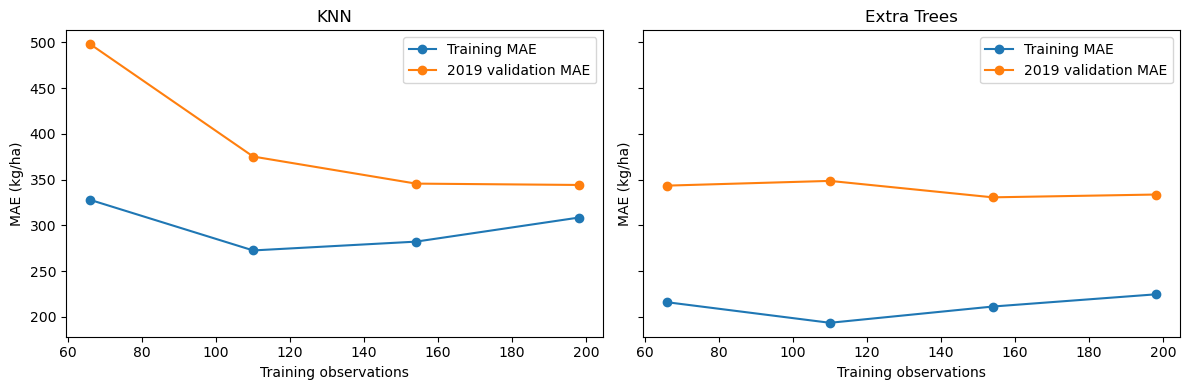

In [38]:
learning_windows = [
    (2013, 2018),
    (2009, 2018),
    (2005, 2018),
    (2001, 2018)
]

finalist_models = {
    "KNN": (
        knn_search.best_estimator_,
        selected_knn_features
    ),
    "Extra Trees": (
        extra_trees_search.best_estimator_,
        selected_extra_trees_features
    )
}

learning_curve_results = []

for model_name, (model, selected_features) in finalist_models.items():

    for training_start, training_end in learning_windows:

        training_mask = training_years.between(
            training_start,
            training_end
        )

        validation_mask = training_years == 2019

        X_learning_train = X_train_screened.loc[
            training_mask,
            selected_features
        ]

        y_learning_train = y_train_no_missing.loc[
            training_mask
        ]

        X_learning_validation = X_train_screened.loc[
            validation_mask,
            selected_features
        ]

        y_learning_validation = y_train_no_missing.loc[
            validation_mask
        ]

        learning_model = clone(model)

        learning_model.fit(
            X_learning_train,
            y_learning_train
        )

        training_predictions = learning_model.predict(
            X_learning_train
        )

        validation_predictions = learning_model.predict(
            X_learning_validation
        )

        learning_curve_results.append({
            "Model": model_name,
            "Training_Period": (
                f"{training_start}–{training_end}"
            ),
            "Training_Observations": len(
                X_learning_train
            ),
            "Training_MAE": mean_absolute_error(
                y_learning_train,
                training_predictions
            ),
            "Validation_MAE": mean_absolute_error(
                y_learning_validation,
                validation_predictions
            )
        })

learning_curve_results = pd.DataFrame(
    learning_curve_results
)

display(learning_curve_results.round(3))

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4),
    sharey=True
)

for axis, model_name in zip(
    axes,
    finalist_models
):
    model_results = learning_curve_results[
        learning_curve_results["Model"] == model_name
    ]

    axis.plot(
        model_results["Training_Observations"],
        model_results["Training_MAE"],
        marker="o",
        label="Training MAE"
    )

    axis.plot(
        model_results["Training_Observations"],
        model_results["Validation_MAE"],
        marker="o",
        label="2019 validation MAE"
    )

    axis.set_title(model_name)
    axis.set_xlabel("Training observations")
    axis.set_ylabel("MAE (kg/ha)")
    axis.legend()

plt.tight_layout()
plt.show()

### Interpretation
KNN benefits substantially from additional historical coverage. Its 2019 validation MAE decreases from 498.04 kg/ha with the 2013–2018 window to 344.24 kg/ha with the full 2001–2018 window. Most of the improvement is achieved by 154 observations, after which performance stabilizes.

Extra Trees records lower 2019 validation MAE across all four training windows, ranging from 330.72 to 348.68 kg/ha. Its validation performance changes little as earlier years are added, suggesting less dependence on the length of the historical training window. However, the larger gap between its training and validation errors indicates greater model complexity and potential overfitting.

Overall, Extra Trees performs better on the fixed 2019 validation year, while KNN shows clearer improvement from additional historical coverage. Since this diagnostic relies on a single validation year, it should support—not determine—the final model choice. Performance across all chronological folds should remain the primary basis for selection.

## Validation Error Analysis

Out-of-fold predictions are examined to understand when and where KNN and Extra Trees produce their largest errors.

Only chronological validation predictions are used, so the 2020–2024 test period remains untouched.

### Validation Performance by Year

MAE and RMSE are calculated separately for each validation year to identify difficult periods and compare model consistency over time.

In [41]:
yearly_validation_performance = (
    country_validation_predictions
    .groupby(["Model", "Year"])
    .apply(
        lambda results: pd.Series({
            "Observations": len(results),
            "MAE": mean_absolute_error(
                results["Actual_Yield"],
                results["Predicted_Yield"]
            ),
            "RMSE": mean_squared_error(
                results["Actual_Yield"],
                results["Predicted_Yield"]
            ) ** 0.5
        }),
        include_groups=False
    )
    .reset_index()
)

yearly_validation_performance["Observations"] = (
    yearly_validation_performance["Observations"]
    .astype(int)
)

display(yearly_validation_performance.round(3))

,Model,Year,Observations,MAE,RMSE
0,Extra Trees,2013,11,345.823,496.546
1,Extra Trees,2014,11,348.353,496.130
2,Extra Trees,2015,11,369.462,486.337
3,Extra Trees,2016,11,367.240,684.384
4,Extra Trees,2017,11,426.245,693.384
5,Extra Trees,2018,11,525.370,757.103
6,Extra Trees,2019,11,333.772,546.549
7,KNN,2013,11,373.438,516.659
8,KNN,2014,11,316.620,467.104
9,KNN,2015,11,346.520,487.263


### Interpretation
Performance varies across validation years, with neither model consistently outperforming the other.

KNN achieves the lower MAE in four of the seven years, while Extra Trees performs better in three.
Both models record their highest MAE in 2018, identifying it as the most difficult validation year.
Extra Trees achieves the lower RMSE in five years, indicating slightly better control of larger prediction errors.

Overall, KNN performs slightly better on average absolute error, while Extra Trees more often limits large errors. The yearly results confirm that both models remain closely competitive and that their relative performance depends on the validation period.

### Largest Validation Errors

The largest absolute errors are examined to identify the country-year observations that were most difficult to predict.

Prediction_Error is defined as predicted yield minus actual yield. Negative values indicate underestimation, while positive values indicate overestimation.

In [42]:
validation_errors = (
    country_validation_predictions
    .assign(
        Prediction_Error=lambda data: (
            data["Predicted_Yield"]
            - data["Actual_Yield"]
        ),
        Absolute_Error=lambda data: (
            data["Predicted_Yield"]
            - data["Actual_Yield"]
        ).abs()
    )
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    validation_errors[
        [
            "Model",
            "Country",
            "Year",
            "Actual_Yield",
            "Predicted_Yield",
            "Prediction_Error",
            "Absolute_Error"
        ]
    ]
    .head(10)
    .round(3)
)

,Model,Country,Year,Actual_Yield,Predicted_Yield,Prediction_Error,Absolute_Error
0,KNN,Egypt,2018,12047.9,9793.040,-2254.860,2254.860
1,KNN,Egypt,2016,11077.2,8876.440,-2200.760,2200.760
2,KNN,Egypt,2017,11921.7,9793.040,-2128.660,2128.660
3,Extra Trees,Egypt,2016,11077.2,8980.898,-2096.302,2096.302
4,Extra Trees,Egypt,2018,12047.9,9956.233,-2091.667,2091.667
5,Extra Trees,Egypt,2017,11921.7,9922.171,-1999.529,1999.529
6,Extra Trees,Egypt,2019,9524.3,11155.248,1630.948,1630.948
7,KNN,Egypt,2019,9524.3,10874.300,1350.000,1350.000
8,KNN,Spain,2013,3700.1,2537.480,-1162.620,1162.620
9,KNN,Egypt,2015,10026.6,8876.440,-1150.160,1150.160


### Interpretation
The largest validation errors are concentrated in Egypt, particularly between 2016 and 2018, when both models substantially underestimated the observed yields. Both models then overestimated Egypt’s yield in 2019. Spain–2013 also produced a large underestimation error.

These errors occur mainly at unusually high yield levels. Their concentration in the same country-year observations suggests that neither model fully captures these cases using the selected predictors. Extra Trees generally produces smaller errors for the most difficult Egyptian observations, consistent with its lower overall RMSE.

Neither model consistently dominates across the validation analyses. However, MAE was defined in advance as the primary selection metric, and KNN achieves:

- the lowest mean validation MAE;
- lower MAE variation than Extra Trees;
- the lower MAE in more countries and validation years;
- a smaller training–validation gap when using the full historical training window.

KNN is therefore selected for final test evaluation. Extra Trees remains a strong alternative, particularly when limiting large prediction errors is the priority.

Evaluation note: Model selection is based entirely on the chronological development folds. The 2020–2024 test period remains untouched and will provide the final independent assessment of KNN’s predictive performance.

## Final Evaluation on the Unseen Test Period

KNN is selected for final evaluation based on the predefined primary metric, MAE, together with its lower validation variability and smaller training–validation gap.

The difference between KNN and Extra Trees is small, so this selection does not imply that KNN is universally superior. The feature subset and hyperparameters were fixed before accessing the test results.

The selected model is fitted on the complete 2001–2019 modeling period and evaluated once on the untouched 2020–2024 test period.

In [ ]:
final_knn_model = clone(
    knn_search.best_estimator_
)

final_knn_model.fit(
    X_train_screened[selected_knn_features],
    y_train_no_missing
)

test_predictions = final_knn_model.predict(
    X_test_screened[selected_knn_features]
)

test_mae = mean_absolute_error(
    y_test_no_missing,
    test_predictions
)

test_rmse = mean_squared_error(
    y_test_no_missing,
    test_predictions
) ** 0.5

test_r2 = r2_score(
    y_test_no_missing,
    test_predictions
)

print("Test period: 2020-2024")
print("Test observations:", len(y_test_no_missing))
print("Test MAE:", round(test_mae, 3), "kg/ha")
print("Test RMSE:", round(test_rmse, 3), "kg/ha")
print("Test R2:", round(test_r2, 3))

Test period: 2020–2024
Test observations: 54
Test MAE: 371.626 kg/ha
Test RMSE: 585.747 kg/ha
Test R2: 0.946


### Interpretation
The selected KNN model achieves a test MAE of 371.63 kg/ha, an RMSE of 585.75 kg/ha, and an R² of 0.946 across the unseen 2020–2024 period.

These results are close to its chronological validation performance of 379.78 kg/ha MAE, 594.88 kg/ha RMSE, and 0.948 R². The limited difference between validation and test results indicates that the model maintained similar predictive performance on later, unseen observations.

The comparison with the previous-year baseline shows whether the improvement observed during model development also holds on the final test period. This final comparison should be used before concluding that KNN improves upon the historical benchmark.

Because pooled metrics may conceal differences in performance across countries, the test errors are examined by country in the following section.

### Test Performance by Country

Test performance is evaluated by country to determine whether the overall KNN results are consistent across the dataset.

MAE and RMSE measure absolute errors in kg/ha, while MAPE expresses prediction error relative to each country’s observed yield level.

In [45]:
test_prediction_results = pd.DataFrame({
    "Country": X_test_no_missing["Country"].to_numpy(),
    "Year": X_test_no_missing["Year"].to_numpy(),
    "Actual_Yield": y_test_no_missing.to_numpy(),
    "Predicted_Yield": test_predictions
})

country_test_performance = (
    test_prediction_results
    .groupby("Country")
    .apply(
        lambda results: pd.Series({
            "Observations": len(results),
            "MAE": mean_absolute_error(
                results["Actual_Yield"],
                results["Predicted_Yield"]
            ),
            "RMSE": mean_squared_error(
                results["Actual_Yield"],
                results["Predicted_Yield"]
            ) ** 0.5,
            "MAPE_pct": (
                (
                    results["Actual_Yield"]
                    - results["Predicted_Yield"]
                ).abs()
                / results["Actual_Yield"]
                * 100
            ).mean()
        }),
        include_groups=False
    )
    .reset_index()
)

country_test_performance["Observations"] = (
    country_test_performance["Observations"]
    .astype(int)
)

country_test_performance = (
    country_test_performance
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(country_test_performance.round(3))

,Country,Observations,MAE,RMSE,MAPE_pct
0,Libya,5,21.184,22.687,2.932
1,Tunisia,5,84.460,84.572,15.040
2,Syria,5,160.096,233.583,13.971
3,Italy,5,205.720,222.864,9.997
4,Morocco,5,287.516,359.353,29.724
5,Algeria,5,321.576,423.918,15.041
6,Greece,4,331.305,341.124,9.771
7,Egypt,5,416.808,495.469,4.331
8,Spain,5,550.776,677.039,28.618
9,Portugal,5,842.068,1092.614,24.583


### Interpretation
Test performance varies substantially across countries.

Libya records the lowest absolute and relative errors, with an MAE of 21.18 kg/ha and a MAPE of 2.9%.
Egypt has a higher absolute MAE of 416.81 kg/ha, but a low MAPE of 4.3%, reflecting its substantially higher yield levels.
Portugal and Türkiye record the highest absolute errors, with MAE values above 840 kg/ha.
Morocco, Spain, and Türkiye show the highest relative errors, with MAPE values close to 30%.

The selected KNN model therefore performs strongly overall but does not generalize equally well across countries. In particular, the higher relative errors for Morocco, Spain, Türkiye, and Portugal indicate where additional country-specific features or modeling strategies may be most valuable.

These results should be interpreted cautiously because most countries contribute only five test observations, while Greece contributes four due to the absent Greece–2024 record.

### Export of Final Prediction Results

The final row-level KNN predictions are exported for use in the SQL and Power BI reporting phase.

The file contains one record per available country-year observation in the unseen 2020–2024 test period, including actual yield, predicted yield, and prediction-error measures.

In [ ]:
final_prediction_results = (
    test_prediction_results
    .assign(
        Prediction_Error=lambda data: (
            data["Predicted_Yield"]
            - data["Actual_Yield"]
        ),
        Absolute_Error=lambda data: (
            data["Predicted_Yield"]
            - data["Actual_Yield"]
        ).abs(),
        Absolute_Percentage_Error=lambda data: (
            (
                data["Predicted_Yield"]
                - data["Actual_Yield"]
            ).abs()
            / data["Actual_Yield"].replace(0, np.nan)
            * 100
        ),
        Model_Name="KNN",
        Dataset_Split="Test"
    )
    [
        [
            "Country",
            "Year",
            "Actual_Yield",
            "Predicted_Yield",
            "Prediction_Error",
            "Absolute_Error",
            "Absolute_Percentage_Error",
            "Model_Name",
            "Dataset_Split"
        ]
    ]
    .sort_values(["Country", "Year"])
    .reset_index(drop=True)
)

assert len(final_prediction_results) == len(y_test_no_missing)
assert not final_prediction_results.duplicated(
    subset=["Country", "Year", "Model_Name"]
).any()

prediction_export_path = "knn_test_predictions.csv"

final_prediction_results.to_csv(
    prediction_export_path,
    index=False
)

print("Exported file:", prediction_export_path)
print("Exported observations:", len(final_prediction_results))
print(
    "Period:",
    f"{final_prediction_results['Year'].min()}-"
    f"{final_prediction_results['Year'].max()}"
)

display(final_prediction_results.head())

Exported file: knn_test_predictions.csv
Exported observations: 54
Period: 2020–2024


,Country,Year,Actual_Yield,Predicted_Yield,Prediction_Error,Absolute_Error,Absolute_Percentage_Error,Model_Name,Dataset_Split
0,Algeria,2020,2460.0,1621.04,-838.96,838.96,34.104065,KNN,Test
1,Algeria,2021,1601.4,1621.04,19.64,19.64,1.226427,KNN,Test
2,Algeria,2022,1807.4,1621.04,-186.36,186.36,10.310944,KNN,Test
3,Algeria,2023,1878.8,1621.04,-257.76,257.76,13.719395,KNN,Test
4,Algeria,2024,1926.2,1621.04,-305.16,305.16,15.842592,KNN,Test


### Interpretation
The export contains 54 test observations covering 2020–2024. The row-count and uniqueness checks confirm that all test predictions are included and that each Country–Year–Model combination appears only once.

Prediction_Error is calculated as predicted yield minus actual yield:

- negative values indicate underestimation;
- positive values indicate overestimation.

The exported error fields support both absolute and relative performance analysis in SQL and Power BI.

Data note: Greece contributes four test observations because Greece–2024 is absent from the Gold dataset.

## Conclusion

This notebook developed and evaluated machine-learning models for predicting annual olive yield across 11 Mediterranean countries.

The modeling workflow preserved temporal order through expanding-window cross-validation and an untouched 2020–2024 test period. Candidate predictors were assessed for target leakage, availability at prediction time, missingness, and redundancy before model training.

Several linear and nonlinear regression models were evaluated under the same chronological framework. KNN, Extra Trees, and Ridge emerged as the strongest candidates, and model-specific feature selection improved all three while reducing the number of predictors.

KNN was selected for final evaluation because it achieved the lowest mean validation MAE, lower MAE variability than Extra Trees, and consistent performance as the historical training window expanded. Its final configuration retained 11 country indicators and four numerical predictors:

Year
Mean_Soil_Moisture_7_28cm
Total_Precipitation_mm
Rural_population_pct
Final Test Performance
Test period: 2020–2024
Test observations: 54
MAE: 371.63 kg/ha
RMSE: 585.75 kg/ha
R²: 0.946

These results closely match the chronological validation performance of 379.78 kg/ha MAE, 594.88 kg/ha RMSE, and 0.948 R², indicating that the selected model maintained similar predictive performance on later, unseen observations.

Performance nevertheless varies across countries. Libya and Egypt record low relative prediction errors, while Morocco, Spain, Portugal, and Türkiye present greater prediction difficulty. The strong overall test results therefore do not translate into uniform accuracy across all countries.

Overall, the final KNN model provides an effective regional approach for estimating annual olive yield within the scope of the available data. However, the model should not be interpreted as equally accurate for every country, as an early-season forecasting system, or as evidence that the selected predictors have causal effects on olive yield.

The exported row-level predictions provide the input for the subsequent SQL and Power BI reporting phase.

## Limitations and Future Perspectives

### Limitations

- **Data volume and resolution:** The dataset contains 274 country-year observations, with 209 fully observed training records available for most models. This limits model complexity and prevents reliable country-specific modeling.

- **Annual data resolution:**  Annual indicators may conceal seasonal conditions during flowering, fruit development, and harvest that are important for olive yield.

- **Model-development uncertainty:**  The same chronological folds were used for feature selection, hyperparameter tuning, and model comparison. Validation results may therefore be somewhat optimistic, although the untouched 2020–2024 test period provides an independent final assessment.

- **Country-level differences:**  Yield patterns and predictor relationships vary substantially across countries. Country indicators capture differences in average yield but cannot fully represent country-specific environmental and agricultural responses.

- **Prediction timing:**  The final model uses current-year precipitation and soil-moisture indicators that may not be fully available early in the production season. The model should therefore be interpreted as an annual yield-estimation framework rather than an early-season forecasting system.

- **Uneven country-level performance:** Most countries contribute only five test observations, while Greece contributes four. Country-level error estimates are therefore sensitive to individual years.

- **Model interpretation:** KNN predicts from similar historical observations rather than estimating direct effects. The selected predictors support prediction but should not be interpreted as causal drivers of olive yield.

### Future Perspectives

Future development could extend the project in several directions:

- expand the historical coverage and number of observations;
- integrate monthly or seasonal indicators for drought, heat stress, and key olive-development stages;
- add subnational data to capture regional differences within countries;
- evaluate interaction terms, hierarchical approaches, or country-specific models when sufficient data become available;
- define an operational prediction date and restrict predictors to information available by that date;
reassess economic indicators if more complete historical data become available;
- compare additional boosting algorithms if the dataset is expanded;
- use permutation importance or local explanation methods to investigate model behavior;
- monitor performance on new annual observations and retrain the model when necessary;
- move the test period forward as new data become available to preserve genuinely unseen evaluation years.